In [ ]:
        {
            "cell_type": "code",
            "id": "#VSC-ae2b10a1",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Error analysis: add as a new cell after your existing prediction code",
                "import numpy as np",
                "import pandas as pd",
                "import matplotlib.pyplot as plt",
                "from sklearn.metrics import mean_absolute_error, mean_squared_error",
                "",
                "# predictions already computed:",
                "# all_log_pred = best_model.predict(X_test)",
                "# all_cost_pred = np.expm1(all_log_pred)",
                "# all_cost_true = np.expm1(y_test)",
                "",
                "# ensure numpy arrays to avoid pandas alignment when assigning columns",
                "all_cost_true_arr = np.asarray(all_cost_true).ravel()",
                "all_cost_pred_arr = np.asarray(all_cost_pred).ravel()",
                "",
                "residual = all_cost_true_arr - all_cost_pred_arr",
                "abs_err = np.abs(residual)",
                "rel_err = abs_err / (all_cost_true_arr + 1e-9)",
                "",
                "print(\"MAE (cost units):\", mean_absolute_error(all_cost_true_arr, all_cost_pred_arr))",
                "print(\"RMSE (cost units):\", np.sqrt(mean_squared_error(all_cost_true_arr, all_cost_pred_arr)))",
                "print(\"Median absolute error:\", np.median(abs_err))",
                "print(\"Median relative error:\", np.median(rel_err))",
                "# SMAPE for robust % error",
                "smape = 100 * np.mean(2 * abs_err / (np.abs(all_cost_true_arr) + np.abs(all_cost_pred_arr) + 1e-9))",
                "print(\"SMAPE (%):\", smape)",
                "",
                "# Top outliers",
                "err_df = X_test.reset_index(drop=True).copy()",
                "err_df['true_cost'] = all_cost_true_arr",
                "err_df['pred_cost'] = all_cost_pred_arr",
                "err_df['abs_err'] = abs_err",
                "err_df['rel_err'] = rel_err",
                "print(\"\\nTop 10 largest absolute errors:\")",
                "display(err_df.sort_values('abs_err', ascending=False).head(10))",
                "",
                "# Visual diagnostics",
                "plt.figure(figsize=(6,4))",
                "plt.hist(abs_err, bins=60)",
                "plt.xlabel(\"Absolute error (cost units)\")",
                "plt.title(\"Error distribution\")",
                "plt.show()",
                "",
                "plt.figure(figsize=(6,6))",
                "plt.scatter(all_cost_true_arr, all_cost_pred_arr, alpha=0.5)",
                "plt.xscale('log'); plt.yscale('log')",
                "plt.plot([all_cost_true_arr.min(), all_cost_true_arr.max()], [all_cost_true_arr.min(), all_cost_true_arr.max()], 'r--')",
                "plt.xlabel(\"Actual cost (log scale)\")",
                "plt.ylabel(\"Predicted cost (log scale)\")",
                "plt.title(\"Predicted vs Actual (log-log)\")",
                "plt.show()"
            ]
        }
df = df.drop(columns="Dev.Type")

Current working directory: c:\Users\Admin\Desktop\Software-Cost-estimation\notebook
✅ Conversion successful!


In [10]:

df.columns

Index(['AFP', 'Input', 'Output', 'Enquiry', 'File', 'Interface', 'Added',
       'Changed', 'Deleted', 'Resource', 'Duration', 'Effort'],
      dtype='object')

In [11]:
df.shape

(499, 12)

In [12]:
hourly_rate = 50.0  # currency units per effort unit

df['Cost'] = df['Effort'] * hourly_rate

# use cost as the target for prediction
X = df.drop(columns=['Effort', 'Cost'])
y = df['Cost']


in the above block we are seperating features and target and below we are spliting the data for training and testing 

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape: ", X_train.shape)
print("Test shape:", X_test.shape)

Train shape:  (399, 11)
Test shape: (100, 11)


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# baseline linear regression (no log-transform, single split, no CV)
#Train
model = LinearRegression()
model.fit(X_train_scaled, y_train)

#Predict
y_pred = model.predict(X_test_scaled)

#Evaluate 
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print("MSE: ", mse)
print("R2 Score: ", r2)


MSE:  50029206266.20669
R2 Score:  0.3342220655199777


In [16]:
# baseline random forest (reference model)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)


Random Forest MSE: 51136522843.0275
Random Forest R2: 0.31948613428396233


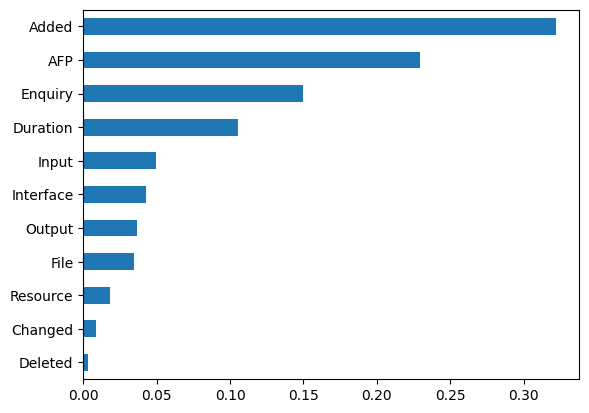

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.show()

In [18]:
# ------------------------------
# Step 1: Feature Engineering
# ------------------------------

import pandas as pd
import numpy as np
import os

# 1️⃣ Load the CSV (update path if needed)
csv_path = os.path.join("..", "data", "processed", "china.csv")  # Adjust folder if different
df = pd.read_csv(csv_path)
print("CSV loaded successfully! Shape:", df.shape)

# 2️⃣ Combine related columns into Functional_Size
df['Functional_Size'] = df['Input'] + df['Output'] + df['Enquiry'] + df['File'] + df['Interface']

# 3️⃣ Create feature ratios / interactions
df['Added_Deleted_Ratio'] = df['Added'] / (df['Deleted'] + 1)          # +1 avoids division by zero
df['Change_Per_Duration'] = (df['Added'] + df['Changed'] + df['Deleted']) / (df['Duration'] + 1)

# 4️⃣ Drop unhelpful or redundant columns
df = df.drop(columns=['ID','Dev.Type','Input','Output','Enquiry','File','Interface','Deleted','Changed'])

# 5️⃣ Compute cost based on effort and a rate
hourly_rate = 50.0  # change to your currency/unit
# cost is linear so SHAP explanations will still apply after multiplying by rate

df['Cost'] = df['Effort'] * hourly_rate

df['Log_Cost'] = np.log1p(df['Cost'])   # log(1 + Cost) avoids log(0)

# ✅ Check the final dataframe
print("\nColumns after feature engineering:")
print(df.columns)
print("\nSample data:")
print(df.head())


CSV loaded successfully! Shape: (499, 19)

Columns after feature engineering:
Index(['AFP', 'Added', 'PDR_AFP', 'PDR_UFP', 'NPDR_AFP', 'NPDU_UFP',
       'Resource', 'Duration', 'N_effort', 'Effort', 'Functional_Size',
       'Added_Deleted_Ratio', 'Change_Per_Duration', 'Cost', 'Log_Cost'],
      dtype='object')

Sample data:
      AFP   Added  PDR_AFP  PDR_UFP  NPDR_AFP  NPDU_UFP  Resource  Duration  \
0  1587.0  1502.0      4.7      5.0       4.7       5.0       4.0       4.0   
1   260.0    51.0     16.0     16.6      16.0      16.6       2.0      17.0   
2   152.0   163.0      4.4      4.1       4.4       4.1       1.0       9.0   
3   252.0    69.0     12.8     14.3      15.5      17.3       1.0       4.0   
4   292.0     0.0     10.3      9.8      12.4      11.7       1.0      13.0   

   N_effort  Effort  Functional_Size  Added_Deleted_Ratio  \
0    7490.0  7490.0           1502.0          1502.000000   
1    4150.0  4150.0            250.0             0.822581   
2     668.0  

In [19]:
# ------------------------------
# Step 2: Train/Test Split + tuned XGBoost pipeline (predicting cost)
# ------------------------------
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# drop the leakage column (N_effort) before modelling
features = ['AFP','Added','Resource','Duration',
            'Functional_Size','Added_Deleted_Ratio','Change_Per_Duration']
target = 'Log_Cost'   # using log-transformed cost

X = df[features]
y = df[target]

# split once and reuse for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape: ", X_train.shape)
print("Test shape:", X_test.shape)

# build a preprocessing+model pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
])

# grid of hyper-parameters
param_grid = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__subsample': [0.7, 1.0]
}

grid = GridSearchCV(
    pipe, param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print("Best parameters found:")
print(grid.best_params_)

best_model = grid.best_estimator_

# evaluate on hold-out test set
y_pred_log = best_model.predict(X_test)
# back-transform predictions and truth to original cost units
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

print("\nFinal test set results (in cost units):")
print("MSE:", mean_squared_error(y_test_orig, y_pred))
print("R² score:", r2_score(y_test_orig, y_pred))


Train shape:  (399, 7)
Test shape: (100, 7)
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found:
{'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}

Final test set results (in cost units):
MSE: 41735816432.134636
R² score: 0.4445887166354434


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


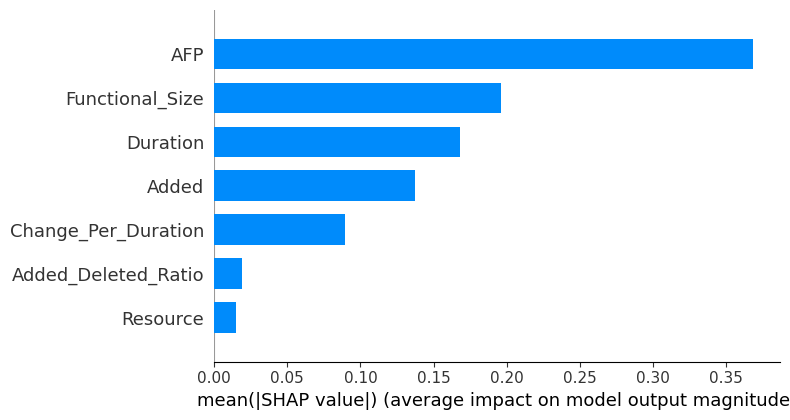

In [20]:
# 🧠 Use SHAP to interpret the tuned XGBoost pipeline (cost model)
import shap

# pipeline consists of a scaler followed by the XGBoost model
scaler = best_model.named_steps['scaler']
xgb_mod = best_model.named_steps['xgb']

# scale features for SHAP explainer
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

explainer = shap.Explainer(xgb_mod, X_train_scaled)
shap_values = explainer(X_test_scaled)

# summary on scaled inputs; contributions are in cost units because target was log-cost
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [21]:
# previous attempt to retrain without N_effort is no longer needed;
# the hyperparameter search above already excluded that column and
# produced the final model used for explanation.


Sample features:
        AFP   Added  Resource  Duration  Functional_Size  Added_Deleted_Ratio  \
460   276.0   177.0       1.0       4.0            244.0                 11.8   
73     75.0     0.0       1.0       5.0             69.0                  0.0   
231   105.0    21.0       1.0       8.0            105.0                 21.0   
175   722.0   622.0       1.0       9.0            622.0                622.0   
237  1710.0  1900.0       2.0      21.0           1900.0               1900.0   

     Change_Per_Duration  
460            48.800000  
73             11.500000  
231            11.666667  
175            62.200000  
237            86.363636  

Predicted log‑cost vs actual log‑cost:
predicted [11.651283 10.892611 10.813497 12.3829   13.231238]
actual    [ 9.61587214  9.63240035  9.20039104 12.24625924 13.3946795 ]

Predicted cost (first 5 rows):
[114837.64   53776.504  49685.9   238684.06  557510.5  ]

Actual cost:
460     15000.0
73      15250.0
231      9900.0
175    20

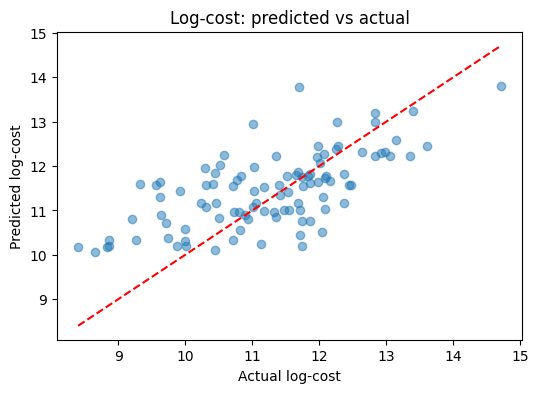

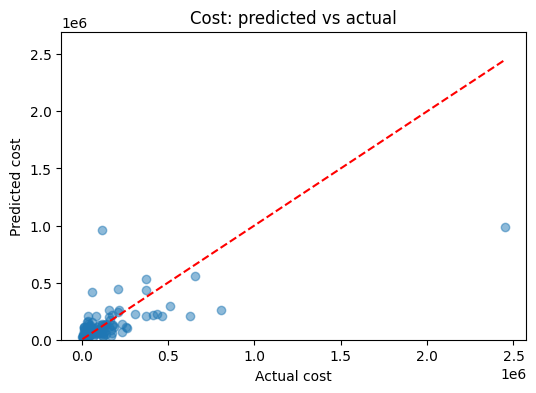

In [22]:
# ------------------------------
# Step 3: example predictions / sanity check
# ------------------------------

# take a few rows from the hold‑out set
sample = X_test.head()

# get both log‑cost and cost predictions
log_pred = best_model.predict(sample)
cost_pred = np.expm1(log_pred)

print("Sample features:")
print(sample)

# show predicted vs true on log scale
print("\nPredicted log‑cost vs actual log‑cost:")
print("predicted", log_pred)
print("actual   ", y_test.head().values)

print("\nPredicted cost (first 5 rows):")
print(cost_pred)

# true cost
true_cost = np.expm1(y_test.head())
print("\nActual cost:")
print(true_cost)

# calculate some simple error metrics for the entire test set
from sklearn.metrics import mean_absolute_error

all_log_pred = best_model.predict(X_test)
all_cost_pred = np.expm1(all_log_pred)
all_cost_true = np.expm1(y_test)

print("\nTest set MAE (cost units):", mean_absolute_error(all_cost_true, all_cost_pred))
print("Test set R² (cost units):", r2_score(all_cost_true, all_cost_pred))

# visual diagnostics: log vs raw
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, all_log_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log-cost')
plt.ylabel('Predicted log-cost')
plt.title('Log-cost: predicted vs actual')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(all_cost_true, all_cost_pred, alpha=0.5)
plt.plot([all_cost_true.min(), all_cost_true.max()], [all_cost_true.min(), all_cost_true.max()], 'r--')
plt.xlabel('Actual cost')
plt.ylabel('Predicted cost')
plt.title('Cost: predicted vs actual')
plt.ylim(0, all_cost_true.max()*1.1)
plt.show()

# you can also save the pipeline for later reuse
#import joblib
#joblib.dump(best_model, 'cost_pipeline.pkl')


MAE (cost units): 96382.03683593748
RMSE (cost units): 204293.45665521114
Median absolute error: 43640.58398437499
Median relative error: 0.5093240078814578
SMAPE (%): 66.35799431370405

Top 10 largest absolute errors:


,AFP,Added,Resource,Duration,Functional_Size,Added_Deleted_Ratio,Change_Per_Duration,true_cost,pred_cost,abs_err,rel_err
55,753.0,672.0,1.0,12.0,672.0,672.0,51.692308,120000.0,256124.187500,843377.875000,7.028149
75,337.0,337.0,1.0,8.0,337.0,337.0,37.444444,213300.0,155738.984375,229950.687500,1.078062
86,58.0,22.0,1.0,5.0,58.0,22.0,9.666667,435300.0,24714.001953,210314.796875,0.483149
9,52.0,0.0,1.0,7.0,46.0,0.0,5.750000,168600.0,36673.714844,131926.285156,0.782481
18,450.0,356.0,1.0,7.0,421.0,44.5,52.625000,176600.0,222349.609375,114781.578125,0.649952
93,220.0,12.0,1.0,4.0,212.0,12.0,42.400000,159450.0,60525.039062,97820.609375,0.613488
79,155.0,148.0,1.0,8.0,148.0,148.0,16.444444,11250.0,106361.242188,96623.742188,8.588777
72,60.0,71.0,1.0,1.0,71.0,71.0,35.500000,14300.0,26390.533203,92061.242188,6.437849
2,105.0,21.0,1.0,8.0,105.0,21.0,11.666667,33400.0,49685.898438,74473.742188,2.229753
63,520.0,430.0,2.0,8.0,430.0,430.0,47.777778,47500.0,199325.734375,72360.453125,1.523378


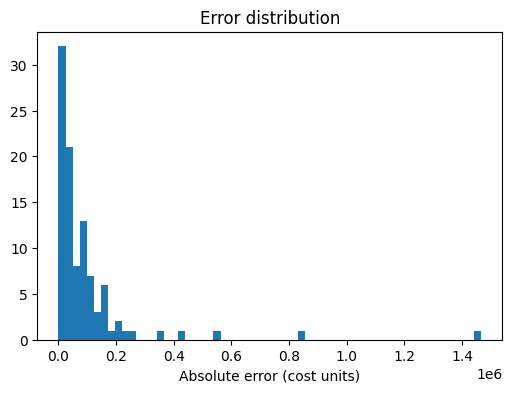

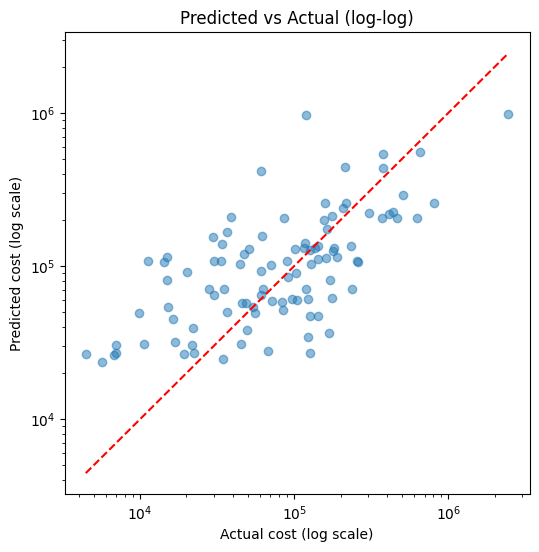